### Extraxtion et transformation du data en dataframe pour faire des analyses

In [1]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
BASE_DIR = os.getcwd()

# 2. On construit le chemin vers 'data' de manière robuste
# Cela fonctionnera même sous Windows ou Linux (gestion des slashs / vs \)
data_path = os.path.join(BASE_DIR, "../data")

print(f"Recherche des fichiers dans : {data_path}")

def build_ner_dataset_v2(directory_path):
    # Ce pattern capture les tags même s'il y a des retours à la ligne ou des espaces variés
    ner_pattern = r"<(\w+)>\s*(.*?)\s*</\1>"
    
    data_list = []
    
    # Vérifier si le dossier existe
    if not os.path.exists(directory_path):
        print(f"Erreur : Le dossier '{directory_path}' est introuvable.")
        return None

    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                for line_num, line in enumerate(f, 1):
                    line = line.strip()
                    if not line:
                        continue
                    
                    # Déterminer le script (Arabe vs Arabizi)
                    # On cherche la présence de caractères arabes (\u0600-\u06FF)
                    has_arabic = bool(re.search(r'[\u0600-\u06FF]', line))
                    script_type = "Arabic" if has_arabic else "Arabizi"
                    
                    # Trouver toutes les entités dans la ligne
                    matches = re.findall(ner_pattern, line)
                    
                    for tag, value in matches:
                        data_list.append({
                            "file": filename,
                            "line_id": line_num,
                            "entity_value": value.strip(),
                            "label": tag,
                            "script": script_type
                        })
    
    df = pd.DataFrame(data_list)
    return df

# Pour l'utiliser :
# df = build_ner_dataset_v2("data/")
# print(df.head())

Recherche des fichiers dans : c:\Users\frekh\Downloads\TextMining\Projet\projet-NER-darija-main\notebook\../data


In [2]:
df1 = build_ner_dataset_v2(f"{data_path}\\raw_annoted\\chatgpt_ner")
df2 = build_ner_dataset_v2(f"{data_path}\\raw_annoted\\Gemini_NER_data")

In [3]:
print(f"shape de prepier dataframe chatgpt : {df1.shape}")
print(f"shape de prepier dataframe Gemini : {df2.shape}")

shape de prepier dataframe chatgpt : (12224, 5)
shape de prepier dataframe Gemini : (130561, 5)


In [4]:
df1.head(20)

,file,line_id,entity_value,label,script
0,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
1,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
2,Akdital NER Tagging.txt,2,ليزاكسون,CARDINAL,Arabic
3,Akdital NER Tagging.txt,2,أكديطال,ORG,Arabic
4,Akdital NER Tagging.txt,2,البورصة,GOV,Arabic
5,Akdital NER Tagging.txt,2,الدولة,GOV_AGG,Arabic
6,Akdital NER Tagging.txt,2,نهار الاثنين,DATE,Arabic
7,Akdital NER Tagging.txt,3,أكديطال,ORG,Arabic
8,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic
9,Akdital NER Tagging.txt,3,ليزاكسون,CARDINAL,Arabic


In [19]:
df1.sample(20)

,file,line_id,entity_value,label,script
12079,هجرة سرية والأزمة الاقتصادية.txt,12,15 smber,DATE,Arabic
11452,مشاكل اقتصاد فرنسا.txt,15,75%,CARDINAL,Arabic
2819,إفلاس الجزائر 2029.txt,7,روسيا,GPE,Arabic
2258,Tagging Moroccan Darija Text.txt,14,mirikan,GPE,Arabic
5092,العقار بالمغرب.txt,7,كأس العالم,EVENT,Arabic
4482,الاقتصاد المغربي وصندوق النقد.txt,4,أمريكا,GPE,Arabic
3723,اقتصاد المغرب 2027.txt,12,بنك المغرب,ORG,Arabic
102,Atay Story and Origins.txt,16,1700,DATE,Arabic
5074,الديون والأبناك التشاركية.txt,22,750 alf,CARDINAL,Arabizi
5520,انتشار الكاش بالمغرب.txt,17,fransa,GPE,Arabic


In [5]:
df1.tail()

,file,line_id,entity_value,label,script
12219,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12220,والي بنك المغرب.txt,28,Turkia,GPE,Arabizi
12221,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12222,والي بنك المغرب.txt,28,lmaghrib,GPE,Arabizi
12223,والي بنك المغرب.txt,28,Turkia,GPE,Arabizi


In [6]:
df2.head()

,file,line_id,entity_value,label,script
0,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,عام 2022,DATE,Arabic
1,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,5 مليون,CARDINAL,Arabic
2,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,2,CARDINAL,Arabic
3,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,الجمعية الأمريكية للطب النفسي,ORG,Arabic
4,"ADHD_ Symptoms, Diagnosis, and Treatment - 98.txt",5,العلماء,PERSON_AGG,Arabic


In [20]:
df2.sample(20)

,file,line_id,entity_value,label,script
89722,Moroccan Real Estate Market Analysis - 177.txt,152,الإدارة,GOV,Arabic
82962,"Moroccan Economy_ Inflation, Tourism, and Jobs...",194,المغرب,GPE,Arabic
52463,Moroccan Darija Financial News Tagging - 141.txt,10,شهر,DATE,Arabic
35449,Iranian Nuclear Program Scenarios - 133.txt,8,iran,GPE,Arabizi
65766,Moroccan Darija NER Tagging Assistant - 31.txt,20,1830,DATE,Arabizi
127111,دعم السكن_ المستفيدون والقطاعات المستفيدة - 26...,97,rrabé,ORDINAL,Arabizi
1478,"Bitcoin, Economy, and Freedom - 21.txt",24,lmstahmitin,PERSON_AGG,Arabizi
106144,Morocco's Tourism Recovery Success - 250.txt,33,lfqr,EVENT_AGG,Arabizi
44166,Moroccan Copyright Law Explained - 69.txt,53,دولار,LANGUAGE,Arabic
32505,Football's Impact on Society - 7.txt,108,المغرب,GPE,Arabic


In [7]:
df2.tail()

,file,line_id,entity_value,label,script
130556,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,tmn snin,DATE,Arabic
130557,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lbanka,ORG,Arabic
130558,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lcontra,LAW,Arabic
130559,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,lbanka,ORG,Arabic
130560,مصر والمغرب_ مقارنة اقتصادية - 135.txt,132,licontat,ORG,Arabic


In [8]:
df = pd.concat([df1,df2],ignore_index=True)

In [9]:
df.shape

(142785, 5)

In [10]:
df['label'].value_counts()

label
GPE                33186
CARDINAL           20740
DATE               15192
ORG                12828
EVENT_AGG          12153
NORP                7346
LOC                 5862
PERSON_AGG          5083
PERSON              3651
GOV_AGG             3462
GOV                 3461
WORK_OF_ART         2499
LAW                 2446
ORG_AGG             2314
EVENT               2251
ORDINAL             1983
MEDIA_AGG           1530
ENTITY_TYPE_AGG     1394
LANGUAGE            1370
MEDIA               1014
ECONOMY_AGG          786
ITEM                 550
CURRENCY             282
NORP_AGG             186
LOC_AGG              172
GPE_AGG              140
PERCENT              122
ENTITY_TYPE          112
CURRENCY_AGG         110
CARDINAL_AGG         106
WORK_OF_ART_AGG       86
RESOURCE              66
LANGUAGE_AGG          62
PRODUCT               56
LAW_AGG               40
ECON_INDICATOR        36
ECONOMIC_TERM         25
PERSON_AGG_AGG        24
LOCATION              11
MISC               

C:\Users\frekh\AppData\Local\Temp\ipykernel_22328\2028129549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=order, palette='viridis')


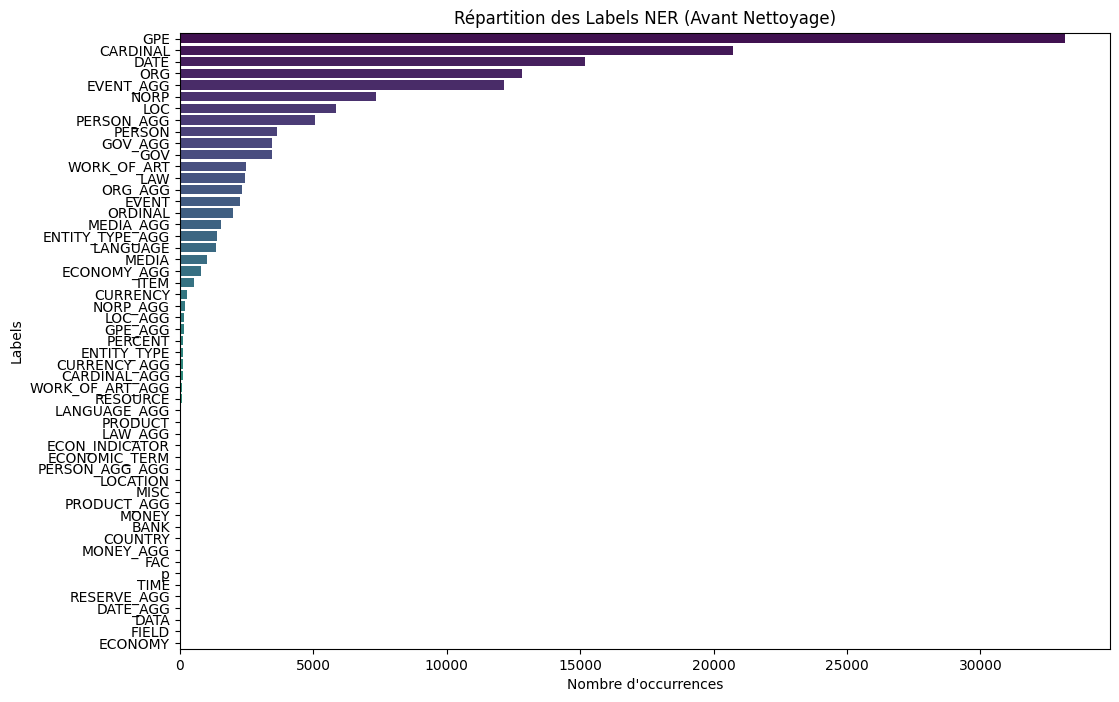

In [11]:
plt.figure(figsize=(12, 8))
order = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=order, palette='viridis')
plt.title('Répartition des Labels NER (Avant Nettoyage)')
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('Labels')
plt.show()


Je vois qu'il ya des entity n'ont pas d'importance et il faut les traiter par exemple :
BANK , TIME ,ECONOMY .. ils sont soit déja une entity qui a le meme reference comme ORG ,DATE ou des entity faut les supp comme FAC FIELD
  
  
il y a aussi des entity faut les fusionner par exemple ORG_AGG pour notre model nous donne plus bons résultats et doubler la puissance

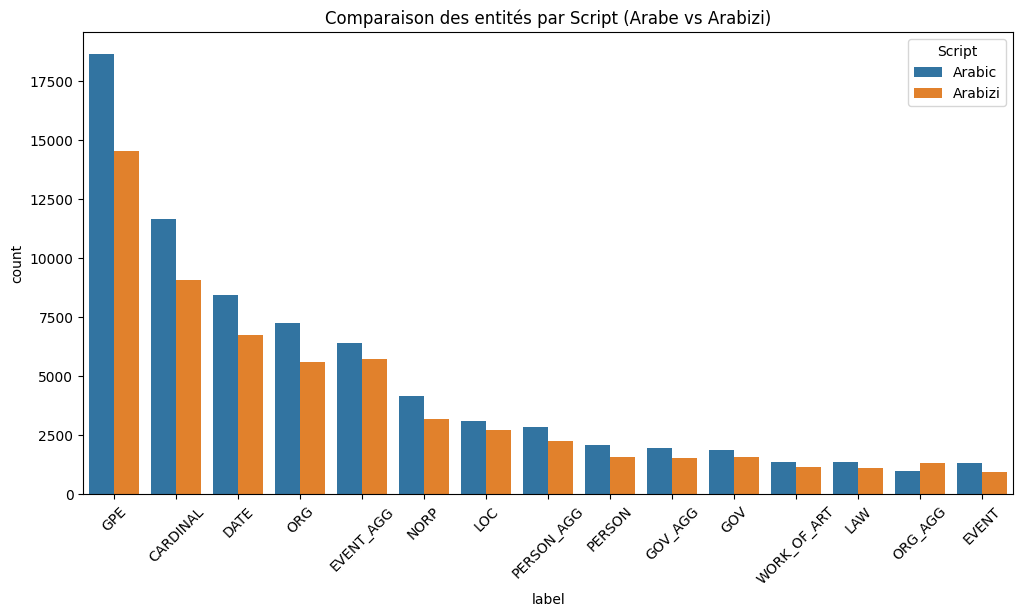

In [12]:
plt.figure(figsize=(12, 6))
# On prend le top 15 pour la lisibilité
top_labels = df['label'].value_counts().head(15).index
df_sub = df[df['label'].isin(top_labels)]

sns.countplot(data=df_sub, x='label', hue='script', order=top_labels)
plt.xticks(rotation=45)
plt.title('Comparaison des entités par Script (Arabe vs Arabizi)')
plt.legend(title='Script')
plt.show()

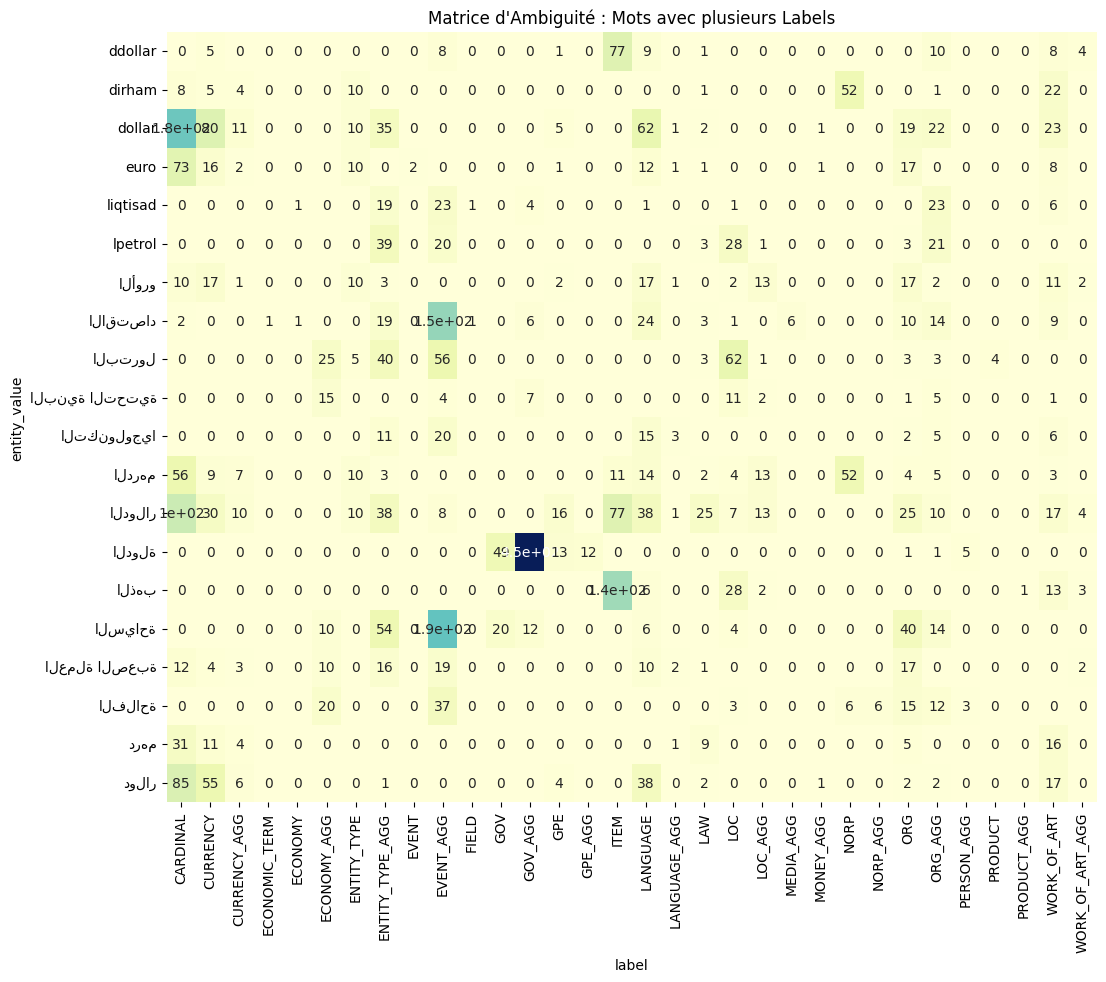

In [13]:
# On cherche les 20 entités les plus fréquentes qui ont plusieurs labels
ambiguity_check = df.groupby('entity_value')['label'].nunique()
ambiguous_words_all = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).index
ambiguous_words = ambiguity_check[ambiguity_check > 1].sort_values(ascending=False).head(20).index

df_ambig = df[df['entity_value'].isin(ambiguous_words)]
df_ambig_all = df[df['entity_value'].isin(ambiguous_words_all)]
pivot_ambig = pd.crosstab(df_ambig['entity_value'], df_ambig['label'])

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_ambig, annot=True, cmap="YlGnBu", cbar=False)
plt.title('Matrice d\'Ambiguité : Mots avec plusieurs Labels')
plt.show()

In [14]:
pivot_ambig

label,CARDINAL,CURRENCY,CURRENCY_AGG,ECONOMIC_TERM,ECONOMY,ECONOMY_AGG,ENTITY_TYPE,ENTITY_TYPE_AGG,EVENT,EVENT_AGG,...,MONEY_AGG,NORP,NORP_AGG,ORG,ORG_AGG,PERSON_AGG,PRODUCT,PRODUCT_AGG,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
ddollar,0,5,0,0,0,0,0,0,0,8,...,0,0,0,0,10,0,0,0,8,4
dirham,8,5,4,0,0,0,10,0,0,0,...,0,52,0,0,1,0,0,0,22,0
dollar,185,80,11,0,0,0,10,35,0,0,...,1,0,0,19,22,0,0,0,23,0
euro,73,16,2,0,0,0,10,0,2,0,...,1,0,0,17,0,0,0,0,8,0
liqtisad,0,0,0,0,1,0,0,19,0,23,...,0,0,0,0,23,0,0,0,6,0
lpetrol,0,0,0,0,0,0,0,39,0,20,...,0,0,0,3,21,0,0,0,0,0
الأورو,10,17,1,0,0,0,10,3,0,0,...,0,0,0,17,2,0,0,0,11,2
الاقتصاد,2,0,0,1,1,0,0,19,0,151,...,0,0,0,10,14,0,0,0,9,0
البترول,0,0,0,0,0,25,5,40,0,56,...,0,0,0,3,3,0,4,0,0,0


In [15]:
pivot_ambig_all = pd.crosstab(df_ambig_all['entity_value'], df_ambig_all['label'])
pivot_ambig_all.head(20)

label,BANK,CARDINAL,CARDINAL_AGG,COUNTRY,CURRENCY,CURRENCY_AGG,DATA,DATE,DATE_AGG,ECONOMIC_TERM,...,ORG_AGG,PERCENT,PERSON,PERSON_AGG,PERSON_AGG_AGG,PRODUCT,PRODUCT_AGG,RESOURCE,WORK_OF_ART,WORK_OF_ART_AGG
entity_value,,,,,,,,,,,,,,,,,,,,,
1,0,70,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,144,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
10 snin,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
10 سنين,0,1,0,0,0,0,0,67,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,31,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,122,0,0,0,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
123,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13%,0,138,0,0,0,0,0,0,0,0,...,0,4,0,0,0,0,0,0,0,0


In [16]:
# voir les cardinals dollar,ddolar.. groupby entity_value et label la place de fichier, compter les occurrences
df[df['entity_value'].str.contains('dollar|دولار|درهم|اورو|euro|dirham', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(20)


,entity_value,label,file,count
0,1 dollar,CARDINAL,Darija AI Discussion and Tagging - 169.txt,1
1,1 dollar,CARDINAL,Darija NER Tagging Assistant Workflow - 176.txt,1
2,1 dollar,CARDINAL,Darija NER Tagging_ Tourism & Economy - 170.txt,1
3,1 dollar,CARDINAL,Darija Text Analysis and Tagging - 175.txt,1
4,1 dollar,CARDINAL,Disappearance of Bank Al-Maghrib Governor - 16...,1
5,1 dollar,CARDINAL,Global Politics and Moroccan Economy - 167.txt,1
6,1 dollar,CARDINAL,Moroccan Census_ Cost vs. Benefit - 173.txt,1
7,1 dollar,CARDINAL,Moroccan Darija Financial Advice - 160.txt,1
8,1 dollar,CARDINAL,Moroccan Darija Investment Advice - 159.txt,1
9,1 dollar,CARDINAL,Moroccan Darija NER Tagging Assistant - 172.txt,1


In [17]:
df[df['entity_value'].str.contains('lpetrol', case=False, na=False)].groupby(['entity_value', 'label', 'file']).size().reset_index(name='count').head(50)


,entity_value,label,file,count
0,lboldan lmontija l lpetrol,NORP,ارتفاع أسعار المحروقات في المغرب - 32.txt,1
1,lpetrol,ENTITY_TYPE_AGG,Algeria's 2025 Budget Analysis - 224.txt,2
2,lpetrol,ENTITY_TYPE_AGG,Darija Bitcoin Seizure and Auction - 240.txt,2
3,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant - 63.txt,1
4,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 229.txt,2
5,lpetrol,ENTITY_TYPE_AGG,Darija NER Tagging Assistant Workflow - 235.txt,2
6,lpetrol,ENTITY_TYPE_AGG,Darija Text Tagging and Rewriting - 61.txt,1
7,lpetrol,ENTITY_TYPE_AGG,Moroccan Car Industry Discussion - 227.txt,2
8,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Budget Law Analysis - 225.txt,2
9,lpetrol,ENTITY_TYPE_AGG,Moroccan Darija Economic & Social Discussion -...,2


## Lmachakiil

Alors, nous avons mis le doigt sur les deux problèmes majeurs liés à l'utilisation de LLMs pour la pré-annotation (Étape C de votre cahier des charges) : l'hallucination de labels (inventer des classes qui n'existent pas dans le prompt) et l'imprécision des frontières d'entités (les spans trop courts ou mal ciblés).

#### 1. Regroupement et nettoyage des labels (Mapping)
Votre cahier des charges impose strictement 14 classes. Tous les autres labels doivent être soit ramenés à une de ces 14 classes (ex: BANK → ORG), soit supprimés s'ils ne correspondent à rien de pertinent (ex: ITEM, p, FAC).

Taille du dataset AVANT nettoyage : 142785 entités
Taille du dataset APRÈS mapping et filtrage : 139734 entités
Nombre d'entités hors-sujet supprimées : 3051\n
--- Détail des entités par label ---
label_mapped
GPE            33330
CARDINAL       21370
DATE           15196
ORG            15146
EVENT          14404
PERSON          8758
NORP            7532
GOV             6923
LOC             6045
WORK_OF_ART     2585
MEDIA           2544
LAW             2486
ORDINAL         1983
LANGUAGE        1432
Name: count, dtype: int64


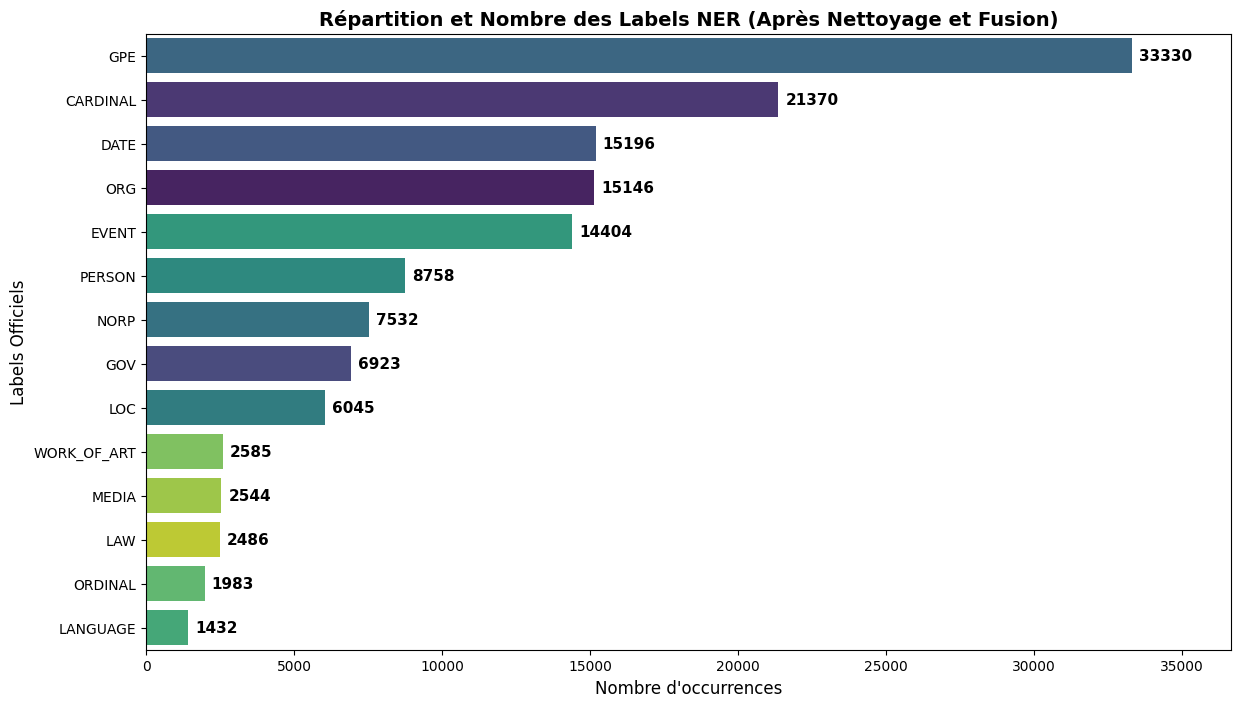

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définir les 14 labels officiels du cahier des charges
official_labels = [
    "PERSON", "NORP", "GPE", "LOC", "ORG", "GOV", "MEDIA", 
    "EVENT", "WORK_OF_ART", "LAW", "LANGUAGE", "DATE", "ORDINAL", "CARDINAL"
]

# 2. Créer un dictionnaire de mapping pour les erreurs courantes du LLM
label_mapping = {
    # Nettoyage des suffixes "_AGG" 
    'EVENT_AGG': 'EVENT', 'PERSON_AGG': 'PERSON', 'GOV_AGG': 'GOV',
    'ORG_AGG': 'ORG', 'MEDIA_AGG': 'MEDIA', 'NORP_AGG': 'NORP',
    'LOC_AGG': 'LOC', 'GPE_AGG': 'GPE', 'WORK_OF_ART_AGG': 'WORK_OF_ART',
    'LANGUAGE_AGG': 'LANGUAGE', 'LAW_AGG': 'LAW', 'PERSON_AGG_AGG': 'PERSON',
    'CARDINAL_AGG': 'CARDINAL',
    
    # Redirection sémantique vers les classes officielles
    'BANK': 'ORG', 
    'COUNTRY': 'GPE', 
    'LOCATION': 'LOC', 
    'TIME': 'DATE',
    'DATE_AGG': 'DATE',
    
    # L'argent et les pourcentages sont ramenés à CARDINAL
    'CURRENCY': 'CARDINAL', 'CURRENCY_AGG': 'CARDINAL', 
    'MONEY': 'CARDINAL', 'MONEY_AGG': 'CARDINAL', 
    'PERCENT': 'CARDINAL'
}

# Copie du dataframe pour travailler proprement
df_clean = df.copy()

# Appliquer le mapping
df_clean['label_mapped'] = df_clean['label'].replace(label_mapping)

# Filtrer pour ne garder QUE les 14 classes officielles (cela supprime automatiquement les labels inutiles)
df_clean = df_clean[df_clean['label_mapped'].isin(official_labels)]

# Afficher un résumé des quantités
print(f"Taille du dataset AVANT nettoyage : {df.shape[0]} entités")
print(f"Taille du dataset APRÈS mapping et filtrage : {df_clean.shape[0]} entités")
print(f"Nombre d'entités hors-sujet supprimées : {df.shape[0] - df_clean.shape[0]}\\n")

print("--- Détail des entités par label ---")
print(df_clean['label_mapped'].value_counts())

# Création du graphique avec les nombres sur les barres
plt.figure(figsize=(14, 8))
order = df_clean['label_mapped'].value_counts().index

# On utilise hue='label_mapped' et legend=False pour éviter l'avertissement de Seaborn
ax = sns.countplot(
    data=df_clean, 
    y='label_mapped', 
    order=order, 
    hue='label_mapped', 
    palette='viridis', 
    legend=False
)

# Boucle pour ajouter le nombre exact à la fin de chaque barre
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

# Ajout des titres et labels
plt.title('Répartition et Nombre des Labels NER (Après Nettoyage et Fusion)', fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'occurrences", fontsize=12)
plt.ylabel("Labels Officiels", fontsize=12)

# Ajuster les marges pour que les nombres ne soient pas coupés
plt.xlim(0, df_clean['label_mapped'].value_counts().max() * 1.1)

plt.show()

#### 2. Détection des problèmes de "Spans" (Frontières des entités)
Pour identifier les entités tronquées (trop courtes) ou les "fuites" où le LLM a annoté une phrase entière (trop longues), nous pouvons analyser la longueur des entités (en nombre de mots et de caractères).

In [28]:
# Calculer le nombre de mots et de caractères pour chaque entité
df_clean['word_count'] = df_clean['entity_value'].apply(lambda x: len(str(x).split()))
df_clean['char_count'] = df_clean['entity_value'].apply(lambda x: len(str(x)))



# --- RECHERCHE D'ANOMALIES ---

# 1. Les entités suspectes car trop longues (Probablement des phrases entières annotées par erreur)
print("--- Entités très longues (Potentielles phrases complètes) ---")
display(df_clean[df_clean['word_count'] > 6][['entity_value', 'label_mapped', 'word_count']].sample(10, random_state=42))

# 2. Les entités d'un seul caractère (Souvent du bruit, de la ponctuation ou des erreurs de tokenization)
print("\\n--- Entités d'un seul caractère (Bruit potentiel) ---")
display(df_clean[df_clean['char_count'] == 1]['entity_value'].value_counts().head(10))

--- Entités très longues (Potentielles phrases complètes) ---


,entity_value,label_mapped,word_count
21556,9 d llil hta l 7 d sbah,DATE,8
2838,markaz dirasa w tafkir 7awl l3alam lfrankofoni,ORG,7
111069,الوكالة المغربية للأمن والسلامة في المجالين ال...,GOV,8
55329,natij dakhili kham</ORG>. Ktab smyto <WORK_OF_...,ORG,14
86666,9 د الليل حتى ل 7 د الصباح,DATE,8
141272,مولات الملوي</PRODUCT> غيغلى عليها الطياب وغاد...,PERSON,10
115437,moassasat lma3ayir wal moraja3a lil moassasat ...,ORG,8
62332,الوكالة الوطنية للتدبير الاستراتيجي لمساهمات ا...,ORG,7
7768,itifaqiyat 7imayat torath 3alami ta9afi w tabi3i,LAW,7
132699,الهيئة الوطنية للنزاهة والوقاية من الرشوة ومحا...,GOV,7


\n--- Entités d'un seul caractère (Bruit potentiel) ---


entity_value
5    333
3    238
4    153
7    104
2     83
1     82
6     78
8     44
9     42
x      1
Name: count, dtype: int64

#### 3. Recherche de caractères parasites et nettoyage de texte
Souvent, les LLMs incluent la ponctuation environnante dans le span (ex: "lmaghrib," au lieu de "lmaghrib"), ce qui est mauvais pour entraîner un modèle NER.

In [29]:
# 1. On définit notre propre liste de ponctuations "parasites" 
# On exclut délibérément '%', '+', '-', '.' qui peuvent être légitimes
suspect_punctuation = '",:;!?()[]{}_«»/\\'

# 2. Fonction pour détecter la ponctuation parasite aux extrémités
def has_suspect_boundary_punctuation(text):
    text = str(text).strip() # On enlève les espaces invisibles d'abord
    if len(text) == 0:
        return False
    # Vérifie si le premier ou le dernier caractère est une ponctuation suspecte
    return text[0] in suspect_punctuation or text[-1] in suspect_punctuation

# 3. Appliquer la détection
df_clean['has_suspect_punct'] = df_clean['entity_value'].apply(has_suspect_boundary_punctuation)

print(f"Nombre d'entités avec de la ponctuation suspecte aux extrémités : {df_clean['has_suspect_punct'].sum()}")

# 4. Afficher un échantillon des anomalies trouvées
if df_clean['has_suspect_punct'].sum() > 0:
    print("\n--- Exemples d'entités mal délimitées par le LLM ---")
    display(df_clean[df_clean['has_suspect_punct'] == True][['entity_value', 'label_mapped']].sample(min(10, df_clean['has_suspect_punct'].sum())))



Nombre d'entités avec de la ponctuation suspecte aux extrémités : 153

--- Exemples d'entités mal délimitées par le LLM ---


,entity_value,label_mapped
65128,एस डी एक्स एनर्जी (SDX Energy),ORG
75749,lkhotot lmalakiya lmghribiya (RAM),ORG
43448,lboraq (TGV),WORK_OF_ART
62395,lmaktab lwatani lissikak lhadidiya (ONCF),ORG
120213,lboraq (TGV),WORK_OF_ART
75687,الخطوط الملكية المغربية (RAM),ORG
52343,lwakala lwataniya liltadbir listratiji limasah...,ORG
76525,الخطوط الملكية المغربية (RAM),ORG
118705,lboraq (TGV),WORK_OF_ART
76522,صناديق الخزينة (CST),GOV


#### 4. Vérification de la cohérence Script / Texte

Vous avez une colonne script (Arabic vs Arabizi). Il est intéressant de vérifier si le LLM ne s'est pas trompé (ex: un mot classé "Arabic" mais qui ne contient que des lettres latines).

c'est pour cela : 

*Le Code Python d'extraction des annotations a corriger :*

In [42]:
import os
import re
import json

def extract_code_switching_anomalies():
    input_dirs = ['../data/chatgpt_ner', '../data/Gemini_NER_data']
    output_dir = '../data_false_code'
    
    os.makedirs(output_dir, exist_ok=True)
    
    entity_pattern = re.compile(r'<([A-Z_]+)>\s*(.*?)\s*</\1>')
    arabic_chars = re.compile(r'[\u0600-\u06FF]')
    latin_chars = re.compile(r'[a-zA-Z]')
    
    anomalies = set()

    for input_dir in input_dirs:
        if not os.path.exists(input_dir):
            continue
            
        for filename in os.listdir(input_dir):
            if not filename.endswith('.txt'):
                continue
                
            filepath = os.path.join(input_dir, filename)
            with open(filepath, 'r', encoding='utf-8') as f:
                current_mode = None
                
                for line in f:
                    line_upper = line.upper()
                    if 'TEXT (ARABIC)' in line_upper or 'TAG_TEXT (ARABIC)' in line_upper:
                        current_mode = 'ARABIC'
                        continue
                    elif 'ARABIZI' in line_upper:
                        current_mode = 'ARABIZI'
                        continue
                        
                    if not current_mode:
                        continue
                        
                    matches = entity_pattern.findall(line)
                    for label, entity in matches:
                        entity = entity.strip()
                        
                        if current_mode == 'ARABIC' and latin_chars.search(entity):
                            anomalies.add((current_mode, label, entity))
                            
                        elif current_mode == 'ARABIZI' and arabic_chars.search(entity):
                            anomalies.add((current_mode, label, entity))

    output_data = []
    for mode, label, entity in sorted(list(anomalies)):
        output_data.append({
            "section": mode,
            "label": label,
            "entity": entity
        })

    output_file = os.path.join(output_dir, 'anomalies_to_fix.json')
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)

if __name__ == "__main__":
    extract_code_switching_anomalies()

*les corriger en utilisant gemini api key*

In [ ]:
import json
import time
import re
import os
from google import genai
from google.genai import types

# 1. Configuration de la NOUVELLE API Gemini (Remplacez par votre clé)
client = genai.Client(api_key="EnterKeyDyalek")

def generer_dictionnaire_correction(input_file='../data_false_code/anomalies_to_fix.json', 
                                    output_file='../data_false_code/correction_dict.json', 
                                    batch_size=40):
    
    # Charger les anomalies
    if not os.path.exists(input_file):
        print(f"Le fichier {input_file} n'existe pas.")
        return
        
    with open(input_file, 'r', encoding='utf-8') as f:
        anomalies = json.load(f)
        
    correction_dict = {}
    print(f"Début du traitement de {len(anomalies)} anomalies en lots de {batch_size}...")
    
    # Traitement par lots (batches)
    for i in range(0, len(anomalies), batch_size):
        batch = anomalies[i:i+batch_size]
        numero_lot = i // batch_size + 1
        print(f"Traitement du lot {numero_lot} ({i+1} à {min(i+batch_size, len(anomalies))})...")
        
        prompt = f"""
        Tu es un linguiste expert en Darija marocaine (arabe marocain et arabizi).
        Voici une liste d'entités qui ont été écrites avec le mauvais alphabet.
        
        Règles strictes de correction :
        1. Si "section" == "ARABIC" : L'entité est en caractères latins (Arabizi). Tu dois la translittérer en caractères ARABES. (ex: "lmaghrib" -> "المغرب")
        2. Si "section" == "ARABIZI" : L'entité est en caractères arabes. Tu dois la translittérer en ARABIZI (caractères latins). (ex: "مصر" -> "masr")
        
        Renvoie UNIQUEMENT un objet JSON valide où la clé est l'entité originale et la valeur est l'entité corrigée.
        Ne rajoute aucun texte avant ou après le JSON.
        
        Données à traiter :
        {json.dumps(batch, ensure_ascii=False, indent=2)}
        """
        
        try:
            # Appel à la nouvelle API avec configuration JSON forcée
            response = client.models.generate_content(
                model='gemini-2.5-flash', # Utilisation du dernier modèle rapide
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json", # Force le modèle à renvoyer du JSON propre
                    temperature=0.1 # Température basse pour éviter les hallucinations
                )
            )
            
            response_text = response.text
            
            # Extraction du JSON
            try:
                batch_dict = json.loads(response_text)
            except json.JSONDecodeError:
                # Sécurité supplémentaire au cas où il y a des balises Markdown
                json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response_text, re.DOTALL)
                if json_match:
                    batch_dict = json.loads(json_match.group(1))
                else:
                    raise ValueError("Impossible de décoder la réponse en JSON.")
                
            # Ajouter les corrections au dictionnaire global
            correction_dict.update(batch_dict)
            
            # Petite pause pour éviter le Rate Limiting (limite de requêtes)
            time.sleep(3)
            
        except Exception as e:
            print(f"Erreur lors du traitement du lot {numero_lot} : {e}")
            
    # Sauvegarder le dictionnaire de correction final
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(correction_dict, f, ensure_ascii=False, indent=4)
        
    print(f"\nTerminé ! {len(correction_dict)} mots corrigés ont été sauvegardés dans '{output_file}'.")

# Exécuter la fonction
if __name__ == "__main__":
    generer_dictionnaire_correction()

Début du traitement de 293 anomalies en lots de 40...
Traitement du lot 1 (1 à 40)...
Traitement du lot 2 (41 à 80)...
Traitement du lot 3 (81 à 120)...
Traitement du lot 4 (121 à 160)...
Traitement du lot 5 (161 à 200)...
Traitement du lot 6 (201 à 240)...
Traitement du lot 7 (241 à 280)...
Traitement du lot 8 (281 à 293)...

Terminé ! 288 mots corrigés ont été sauvegardés dans '../data_false_code/correction_dict.json'.
